In [2]:
import pandas as pd

df = pd.read_csv("/content/diabetes_unclean - diabetes_unclean.csv")

df.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [3]:
df.drop(columns=["ID", "No_Pation"], inplace=True)
df

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,M,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...
1004,M,55.0,NaN,62.0,6.8,5.3,2.0,1.0,3.5,0.9,30.1,Y
1005,M,55.0,4.8,88.0,NaN,5.7,4.0,0.9,3.3,1.8,30.0,Y
1006,M,62.0,6.3,82.0,6.7,5.3,2.0,1.0,3.5,NaN,30.1,Y
1007,F,57.0,4.1,70.0,9.3,5.3,3.3,1.0,1.4,1.3,29.0,Y


In [4]:
df["Gender"].unique()

array(['F', 'M', 'f'], dtype=object)

In [5]:
df["Gender"] = df["Gender"].astype(str).str.strip().str.upper()

In [6]:
df["Gender"].unique()

array(['F', 'M'], dtype=object)

In [7]:
df.isnull().sum()

,0
Gender,0
AGE,1
Urea,1
Cr,2
HbA1c,3
Chol,2
TG,2
HDL,1
LDL,2
VLDL,1


In [8]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [9]:
df.fillna(df.mode().iloc[0], inplace=True)

In [10]:
num_cols = ["AGE", "Urea", "Cr", "HbA1c", "Chol", "TG", "HDL", "LDL", "VLDL"]

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [11]:
df.isnull().sum()

,0
Gender,0
AGE,0
Urea,0
Cr,0
HbA1c,0
Chol,0
TG,0
HDL,0
LDL,0
VLDL,0


In [12]:
df["CLASS"].unique()

array(['N', 'P', 'Y'], dtype=object)

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["CLASS"] = le.fit_transform(df["CLASS"])

In [14]:
df["CLASS"].unique()

array([0, 1, 2])

In [15]:
df = pd.get_dummies(df, columns=["Gender"], drop_first=True)

In [16]:
X = df.drop("CLASS", axis=1)
y = df["CLASS"]

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

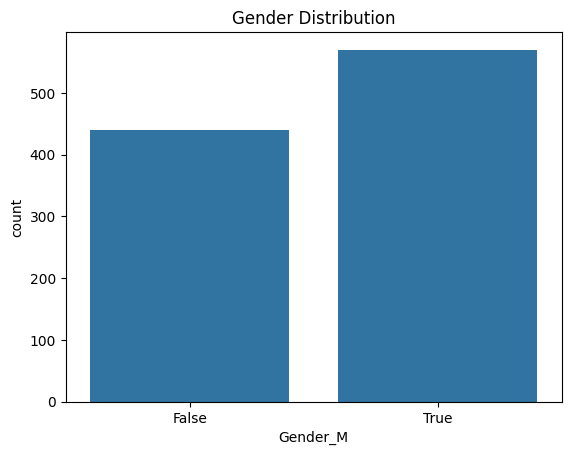

In [18]:
sns.countplot(x="Gender_M", data=df)
plt.title("Gender Distribution")
plt.show()

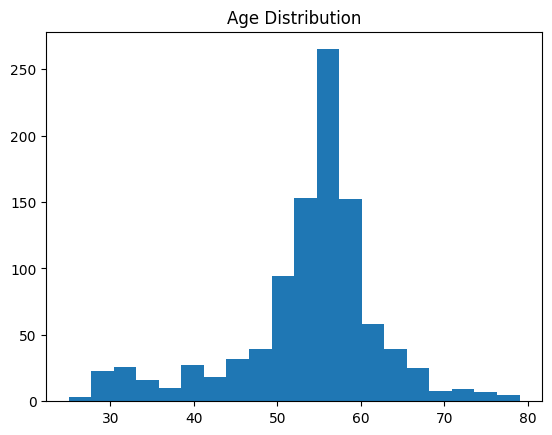

In [19]:
plt.hist(df["AGE"], bins=20)
plt.title("Age Distribution")
plt.show()

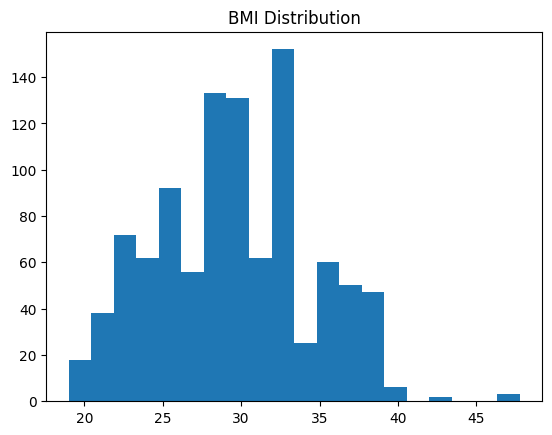

In [20]:
plt.hist(df["BMI"], bins=20)
plt.title("BMI Distribution")
plt.show()

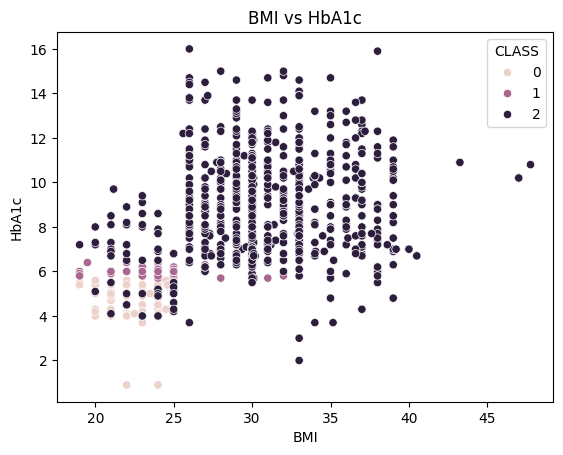

In [21]:
sns.scatterplot(x="BMI", y="HbA1c", hue="CLASS", data=df)
plt.title("BMI vs HbA1c")
plt.show()

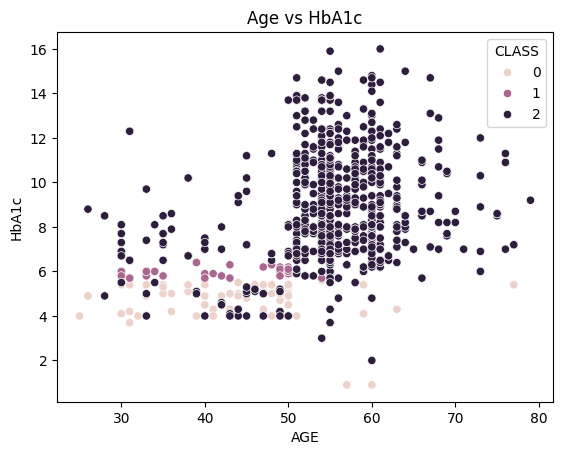

In [22]:
sns.scatterplot(x="AGE", y="HbA1c", hue="CLASS", data=df)
plt.title("Age vs HbA1c")
plt.show()

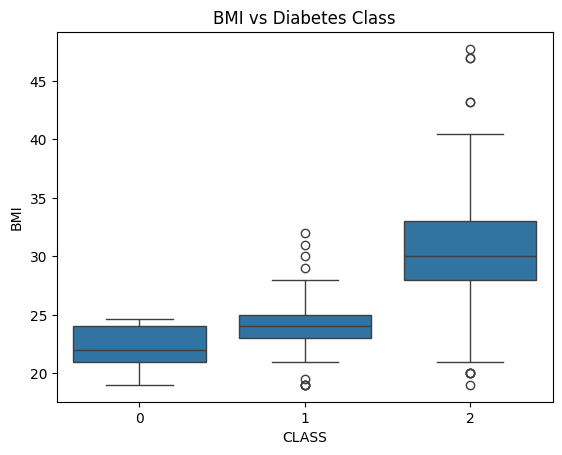

In [23]:
sns.boxplot(x="CLASS", y="BMI", data=df)
plt.title("BMI vs Diabetes Class")
plt.show()

In [24]:
from sklearn.model_selection import train_test_split

X = df.drop("CLASS", axis=1)
y = df["CLASS"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [26]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()
}

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average="weighted"),
        recall_score(y_test, y_pred, average="weighted"),
        f1_score(y_test, y_pred, average="weighted")
    ])

results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score"
])

results_df

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.940594,0.935873,0.940594,0.937243
1,SVM,0.848185,0.719417,0.848185,0.778512
2,Decision Tree,0.986799,0.986781,0.986799,0.986668
3,Random Forest,0.990099,0.990125,0.990099,0.990022
4,KNN,0.907591,0.919991,0.907591,0.913022


In [28]:
best_model_name = results_df.sort_values(by="F1 Score", ascending=False).iloc[0]["Model"]
best_model_name

'Random Forest'

In [29]:
best_model = models[best_model_name]
best_model

RandomForestClassifier()

In [30]:
best_model.fit(X_train, y_train)

RandomForestClassifier()

In [31]:
import joblib

joblib.dump(best_model, "diabetes_model.pkl")

['diabetes_model.pkl']

In [32]:
joblib.dump(X.columns, "training_columns.pkl")

['training_columns.pkl']

In [34]:
from google.colab import files

files.download("diabetes_model.pkl")
files.download("training_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>